In [ ]:
import time

import pandas
from matplotlib import pyplot as plt

from funbin import funbin
from funbin.penrose import penrose_tiling

# Penrose tilings

## Penrose P1: H-G diagram with HYG star catalog

- [Data source](https://codeberg.org/astronexus/hyg)
- Based loosely on [this notebook](https://github.com/RobertoIA/Hertzsprung-Russell)


In [31]:
hyg = pandas.read_csv("misc/hyg_v42.csv.gz")
hyg = hyg[["absmag", "ci"]]
hyg.dropna(inplace=True)
hyg = hyg[hyg["ci"] < 2.25]

print(hyg.size)
hyg.head()

235100


,absmag,ci
0,4.850,0.656
1,2.390,0.482
2,5.866,0.999
3,-1.619,-0.019
4,2.421,0.370


In [40]:
start = time.time()
penrose_p1 = penrose_tiling(kind="P1", bins=(80, 80))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 27.579 sec


(18.675999999999995, -16.68)

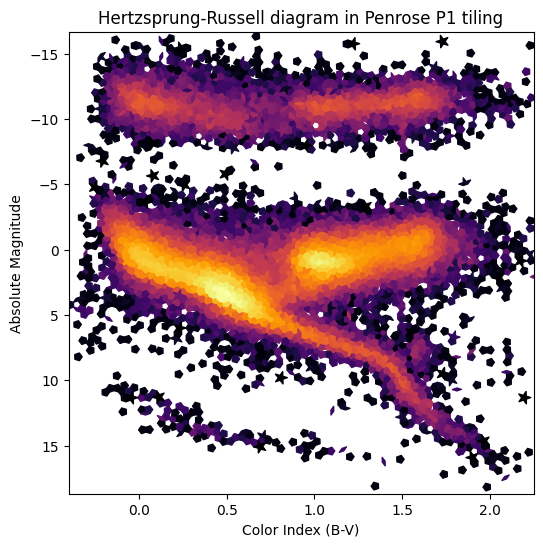

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))

pc = funbin(
    ax,
    x=hyg["ci"].to_numpy(),
    y=hyg["absmag"].to_numpy(),
    tiling=penrose_p1,
    norm="log",
    cmap="inferno",
    # edgecolors="lightgray",
    # linewidth=0.3,
)
# fig.colorbar(pc, ax=ax)
ax.set_title("Hertzsprung-Russell diagram in Penrose P1 tiling")
ax.set_xlabel("Color Index (B-V)")
ax.set_ylabel("Absolute Magnitude")
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymax, ymin)
# fig.savefig(".png", dpi=72)